# Nius
Load Nius CSV files and create a DataFrame named `df`.

In [1]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Nius"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
pd.reset_option('display.max_colwidth')
df.head()


Loaded 4885 rows from 285 file(s) in /Users/katinkakurz/projects/Thesis/data/raw/Alternative Medien/Nius


,id,title,titleHtml,intro,articleRef,categoryRef,articleAltRef,images,tags,video,...,isPaidContent,isTopClickModule,topClickCustomContent,showSystemTeaserTitle,meta,url,day,article_text,source,source_file
0,0682defd-0f5f-4469-812b-20d7cca70273,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,<span>Zitter-Wahl oder Durchmarsch: Wie sicher...,NaN,/politik/news/zitter-wahl-oder-durchmarsch-wie...,/politik,/articles/zitter-wahl-oder-durchmarsch-wie-sic...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,"{'title': ""Zitter-Wahl oder Durchmarsch: Wie s...",https://www.nius.de/politik/news/zitter-wahl-o...,2025-05-01,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,Nius,nius_2025-05-01.csv
1,53d0259d-761e-4377-84b8-12185aaf54e8,"Erst fällt die Brandmauer, dann fließen Tränen...","<span>Erst fällt die Brandmauer, dann fließen ...",NaN,/gesellschaft/news/brandmauer-wurzen-demokrati...,/gesellschaft,/articles/brandmauer-wurzen-demokratie-netzwer...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,"{'title': 'Erst fällt die Brandmauer, dann fli...",https://www.nius.de/gesellschaft/news/brandmau...,2025-05-01,"# Erst fällt die Brandmauer, dann fließen Trän...",Nius,nius_2025-05-01.csv
2,4535cc72-254b-4fd5-a7b6-24a24de52784,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",<span>Als Merkel noch mal „Wir schaffen das“ s...,NaN,/gesellschaft/news/angela-merkel-evangelischer...,/gesellschaft,/articles/angela-merkel-evangelischer-kirchent...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Als Merkel noch mal „Wir schaffen d...,https://www.nius.de/gesellschaft/news/angela-m...,2025-05-01,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",Nius,nius_2025-05-01.csv
3,3c62c613-6cb8-49da-a8f6-c3727a9e55b6,Absage an Transideologie: Englischer Fußballve...,<span>Absage an Transideologie: Englischer Fuß...,NaN,/sport/news/absage-an-transideologie-englische...,/sport,/articles/absage-an-transideologie-englischer-...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Absage an Transideologie: Englische...,https://www.nius.de/sport/news/absage-an-trans...,2025-05-01,# Absage an Transideologie: Englischer Fußball...,Nius,nius_2025-05-01.csv
4,152af3f3-137d-4a51-8f8c-5bf8c5cdbe8b,Ex-Briten-Premier Tony Blair: Bisherige Klima...,<span>Ex-Briten-Premier Tony Blair: Bisherige...,NaN,/politik/news/ex-briten-premier-tony-blair-bis...,/politik,/articles/ex-briten-premier-tony-blair-bisheri...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Ex-Briten-Premier Tony Blair: Bish...,https://www.nius.de/politik/news/ex-briten-pre...,2025-05-01,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,Nius,nius_2025-05-01.csv


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4885 entries, 0 to 4884
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4885 non-null   str    
 1   title                  4885 non-null   str    
 2   titleHtml              4885 non-null   str    
 3   intro                  3 non-null      object 
 4   articleRef             4885 non-null   str    
 5   categoryRef            4885 non-null   str    
 6   articleAltRef          4885 non-null   str    
 7   images                 4885 non-null   str    
 8   tags                   4885 non-null   str    
 9   video                  0 non-null      float64
 10  categories             4885 non-null   str    
 11  slug                   4885 non-null   str    
 12  lastModified           4885 non-null   str    
 13  created                4885 non-null   str    
 14  publishedAt            4885 non-null   str    
 15  template       

## Data Cleaning

In [4]:
df_clean = df[['title', 'categories', 'day', 'authors', 'article_text', 'url']].copy()
df_clean.head()

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,"[{'id': '644a4264f03076c588c3da92', 'email': '...",# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,"[{'id': '64ac16eb3450f0e44302535e', 'email': '...","# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...","# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,"[{'id': '644a43e2f03076c588c3dad6', 'email': '...",# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [5]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4885 entries, 0 to 4884
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         4885 non-null   str  
 1   categories    4885 non-null   str  
 2   day           4885 non-null   str  
 3   authors       4885 non-null   str  
 4   article_text  4872 non-null   str  
 5   url           4885 non-null   str  
dtypes: str(6)
memory usage: 229.1 KB


In [6]:
nan_counts = df_clean.isna().sum()
total_nans = int(nan_counts.sum())

print(f"Any NaNs in df: {total_nans > 0}")
print(f"Total NaN values: {total_nans}")

Any NaNs in df: True
Total NaN values: 13


In [7]:
# Clean the data by dropping rows with NaN values
df_clean = df_clean.dropna()
print(f"Rows after dropping NaNs: {len(df_clean)}")

Rows after dropping NaNs: 4872


In [8]:
# Check duplicates by URL
url_duplicates = df_clean[df_clean.duplicated(subset=['url'], keep=False)]
print(f"Duplicate URLs: {len(url_duplicates)} rows ({url_duplicates['url'].nunique()} unique URLs)")

# Check duplicates by Title
title_duplicates = df_clean[df_clean.duplicated(subset=['title'], keep=False)]
print(f"Duplicate Titles: {len(title_duplicates)} rows ({title_duplicates['title'].nunique()} unique Titles)")

# Check duplicates by Text
text_duplicates = df_clean[df_clean.duplicated(subset=['article_text'], keep=False)]
print(f"Duplicate Text: {len(text_duplicates)} rows")

# Show duplicate URLs if any
if len(url_duplicates) > 0:
    print("\n--- Sample Duplicate URLs ---")
    print(url_duplicates[['day', 'article_text', 'url']].head(10))

Duplicate URLs: 0 rows (0 unique URLs)
Duplicate Titles: 2 rows (1 unique Titles)
Duplicate Text: 2 rows


In [9]:
#Clean author name
import re

def extract_author_name(authors_str):
    """Extract author name(s) from the authors column."""
    if pd.isna(authors_str) or authors_str is None:
        return None
    
    # Convert to string if not already
    authors_str = str(authors_str)
    
    # Use regex to extract all 'name': 'value' patterns directly
    matches = re.findall(r"'name':\s*'([^']*)'", authors_str)
    if matches:
        return ', '.join(matches)
    
    # Try double quotes as well
    matches = re.findall(r'"name":\s*"([^"]*)"', authors_str)
    if matches:
        return ', '.join(matches)
    
    return None

# Apply to the dataframe
df_clean['authors'] = df_clean['authors'].apply(extract_author_name)
df_clean.head()
   

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [10]:
#pd.set_option('display.max_colwidth', None)
df_clean.head(5)

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [11]:
def remove_trailing_nius_reference(text):
    """Remove trailing 'Mehr NIUS:', 'Auch bei NIUS:', etc. from article text."""
    if pd.isna(text) or text is None:
        return text
    
    # Pattern to match trailing NIUS references at the end of the text
    # Matches variations like "Mehr NIUS:", "Mehr bei NIUS:", "Auch bei NIUS:", etc.
    # followed by any remaining text until the end
    pattern = r'\n*(?:Mehr|Auch|Lesen\s+[Ss]ie\s+auch)\s+(?:bei\s+)?NIUS\s*:.*$'
    
    cleaned = re.sub(pattern, '', str(text), flags=re.IGNORECASE | re.DOTALL)
    return cleaned.strip()

df_clean['article_text'] = df_clean['article_text'].apply(remove_trailing_nius_reference)
df_clean.head(10)

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...
5,„Wir neigen zu fürchterlicher Herablassung“: H...,"['Schuler! Fragen, was ist']",2025-05-01,Ralf Schuler,# „Wir neigen zu fürchterlicher Herablassung“:...,"https://www.nius.de/schuler!-fragen,-was-ist/n..."
6,US-Außenminister Marco Rubio folgt auf gefeuer...,['Ausland'],2025-05-01,Redaktion,# US-Außenminister Marco Rubio folgt auf gefeu...,https://www.nius.de/ausland/news/us-aussenmini...
7,Schüsse und Stiche während 1. Mai-Demo: Zwei S...,['Kriminalität'],2025-05-01,Redaktion,# Schüsse und Stiche während 1. Mai-Demo: Zwei...,https://www.nius.de/kriminalitaet/news/berlin-...
8,Verurteilter IS-Unterstützer aus Syrien verlan...,['Kriminalität'],2025-05-02,Redaktion,# Verurteilter IS-Unterstützer aus Syrien verl...,https://www.nius.de/kriminalitaet/news/tischen...
9,Die linke Kaderschmiede im Innenministerium: W...,['Politik'],2025-05-02,Björn Harms,# Die linke Kaderschmiede im Innenministerium:...,https://www.nius.de/politik/news/bundeszentral...


In [12]:
# Remove newline characters from article_text
df_clean['article_text'] = df_clean['article_text'].str.replace('\n', ' ', regex=False)
df_clean.head()

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [13]:
# Extract relevant time period
# Convert 'day' column to datetime 
df_clean['day'] = pd.to_datetime(df_clean['day'])

# Filter for articles from August 2025 to January 2026
start_date = '2025-08-01'
end_date = '2026-01-31'

df_clean = df_clean[(df_clean['day'] >= start_date) & (df_clean['day'] <= end_date)]
print(f"Rows after filtering to {start_date} - {end_date}: {len(df_clean)}")
df_clean.head()

Rows after filtering to 2025-08-01 - 2026-01-31: 3273


,title,categories,day,authors,article_text,url
1424,Das Bürgergeld-Leben der afghanischen Familie B.,['Gesellschaft'],2025-08-01,"Jan A. Karon, Björn Harms",# Das Bürgergeld-Leben der afghanischen Famili...,https://www.nius.de/gesellschaft/news/buergerg...
1425,Die Planwirtschaft von Ursula von der Leyen ha...,['Politik'],2025-08-01,Kurt Lauk,# Die Planwirtschaft von Ursula von der Leyen ...,https://www.nius.de/politik/news/die-planwirts...
1426,Jeder vierte Ausländer (20-25) geht nicht zu S...,['Gesellschaft'],2025-08-01,Redaktion,# Jeder vierte Ausländer (20-25) geht nicht zu...,https://www.nius.de/gesellschaft/news/jeder-vi...
1427,Polizei schickt Deutschen Schäferhund in Rente,['Kommentar'],2025-08-01,Louis Hagen,# Polizei schickt Deutschen Schäferhund in Ren...,https://www.nius.de/kommentar/news/polizei-sch...
1428,Kosovo-Clan schlägt Frau auf offener Straße zu...,['Kriminalität'],2025-08-01,Helena Gebhard,# Kosovo-Clan schlägt Frau auf offener Straße ...,https://www.nius.de/kriminalitaet/news/kosovo-...


In [14]:
df_clean['categories'].value_counts()

categories
['Politik']                     861
['Kommentar']                   295
['Wirtschaft']                  263
['Kriminalität']                248
['Gesellschaft']                243
['Ausland']                     241
['Nachrichten']                 237
['NIUS Live']                   223
['Analyse']                     176
['Medien']                      159
['Kissler Kompakt']              83
['Unterhaltung']                 63
['Schuler! Fragen, was ist']     48
['Statistik']                    28
['Gio unzensiert']               19
['Interview']                    15
['Sport']                        13
[]                               13
['Berlin']                       13
['Nius Originals']               13
['Energie']                      11
['Corona']                        4
['Achtung, Reichelt!']            2
['Show']                          2
Name: count, dtype: int64

In [15]:
# Filter for rows with empty categories
empty_categories = df_clean[df_clean['categories'] == '[]']
print(f"Number of articles with empty categories: {len(empty_categories)}")
print(f"\nPercentage of total: {len(empty_categories) / len(df_clean) * 100:.2f}%")
print(f"\nSample of articles with empty categories:")
empty_categories[['title', 'categories', 'day', 'authors','article_text']].head(10)

Number of articles with empty categories: 13

Percentage of total: 0.40%

Sample of articles with empty categories:


,title,categories,day,authors,article_text
1554,Trump und Putin treffen sich am Freitag in Alaska,[],2025-08-09,Redaktion,# Trump und Putin treffen sich am Freitag in A...
1896,Exklusives Gewinnspiel bei NIUS,[],2025-09-01,Redaktion,# Exklusives Gewinnspiel bei NIUS Willkommen ...
3198,Gewalt an Schulen geht durch die Decke - vor a...,[],2025-11-09,Redaktion,# Gewalt an Schulen geht durch die Decke - vor...
3209,Mann nach Festnahme wieder auf freiem Fuß: 17-...,[],2025-11-10,Redaktion,# Mann nach Festnahme wieder auf freiem Fuß: 1...
3264,Das war NIUS Live am Abend: Rentenstreit eskal...,[],2025-11-11,Redaktion,# Das war NIUS Live am Abend: Rentenstreit esk...
3631,Gründungsparteitag der AfD-Jugend in Gießen: D...,[],2025-11-28,"Jan A. Karon, Björn Harms",# Gründungsparteitag der AfD-Jugend in Gießen:...
3746,Neue Studie: Rechtsextremismus besorgt Deutsch...,[],2025-12-07,Redaktion,# Neue Studie: Rechtsextremismus besorgt Deuts...
4051,Siemens-Bahnchef Michael Peter: Von Berlin nac...,[],2025-12-23,Redaktion,# Siemens-Bahnchef Michael Peter: Von Berlin n...
4056,„Erlauben Sie ihnen die Einreise nach Deutschl...,[],2025-12-23,Redaktion,# „Erlauben Sie ihnen die Einreise nach Deutsc...
4064,Selenskyj legt 20-Punkte-Entwurf für möglichen...,[],2025-12-24,Redaktion,# Selenskyj legt 20-Punkte-Entwurf für möglich...


In [16]:
# Filter for rows with Show categories
show_categories = df_clean[df_clean['categories'].str.contains('Show', na=False)]
print(f"Number of articles with 'Show' category: {len(show_categories)}")
print(f"\nPercentage of total: {len(show_categories) / len(df_clean) * 100:.2f}%")
print(f"\nSample of articles with 'Show' category:")
show_categories[['title', 'categories', 'day', 'authors', 'article_text']].head(10)

Number of articles with 'Show' category: 2

Percentage of total: 0.06%

Sample of articles with 'Show' category:


,title,categories,day,authors,article_text
3346,Exklusiv: Frag Pauline Voss Live am Montag,['Show'],2025-11-14,"Helena Gebhard, Pauline Voss",# Exklusiv: Frag Pauline Voss Live am Montag ...
4685,Exklusiv: Grill den Reichelt Live am Donnerstag!,['Show'],2026-01-30,Redaktion,# Exklusiv: Grill den Reichelt Live am Donners...


Category 'Show' seems to be advertisement, therefore deleted from dataset

In [17]:
# Drop rows where categories contains 'Show'
df_clean = df_clean[~df_clean['categories'].str.contains('Show', na=False)]
print(f"Rows after dropping 'Show' category: {len(df_clean)}")

Rows after dropping 'Show' category: 3271


In [18]:
df_clean['authors'].value_counts()

authors
Redaktion                       1876
Ralf Schuler                     174
Claudio Casula                   115
Alexander Kissler                 95
Felix Perrefort                   88
                                ... 
Sigrid Herrmann                    1
Jens Winter, Jan A. Karon          1
Ute Oelker                         1
Jan A. Karon, Jens Winter          1
Eric Steinberg, Jan A. Karon       1
Name: count, Length: 88, dtype: int64

## EDA

In [19]:
# Create a table showing number of articles per month
articles_per_month = df_clean.groupby(df_clean['day'].dt.to_period('M')).size().reset_index(name='article_count')
articles_per_month.columns = ['month', 'article_count']
articles_per_month

,month,article_count
0,2025-08,465
1,2025-09,563
2,2025-10,585
3,2025-11,603
4,2025-12,508
5,2026-01,547


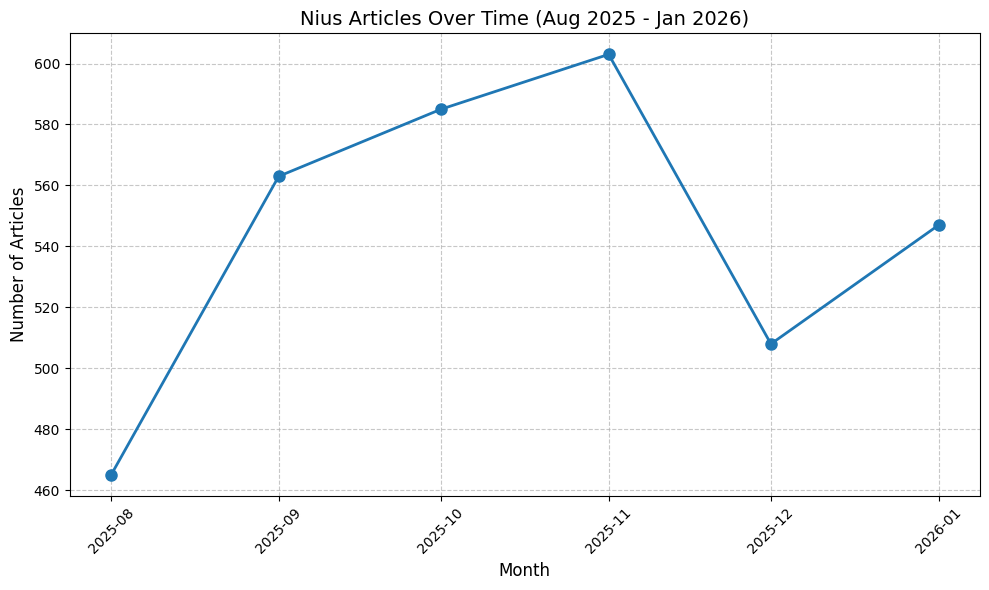

In [20]:
import matplotlib.pyplot as plt

# Create a time series plot of articles per month
fig, ax = plt.subplots(figsize=(10, 6))

# Convert period to timestamp for plotting
articles_per_month['month_ts'] = articles_per_month['month'].dt.to_timestamp()

ax.plot(articles_per_month['month_ts'], articles_per_month['article_count'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Nius Articles Over Time (Aug 2025 - Jan 2026)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy()
eda_df["day"] = pd.to_datetime(eda_df["day"], errors="coerce")

eda_df["article_text"] = eda_df["article_text"].astype("string")
eda_df = eda_df.dropna(subset=["day", "article_text"]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 3,271


In [22]:
eda_df["article_length_words"] = eda_df["article_text"].str.split().str.len()
eda_df["article_length_chars"] = eda_df["article_text"].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    3271.0
mean      560.7
std       507.9
min         4.0
10%       139.0
25%       241.0
50%       418.0
75%       680.0
90%      1168.0
95%      1596.0
99%      2439.0
max      5932.0
Name: article_length_words, dtype: float64

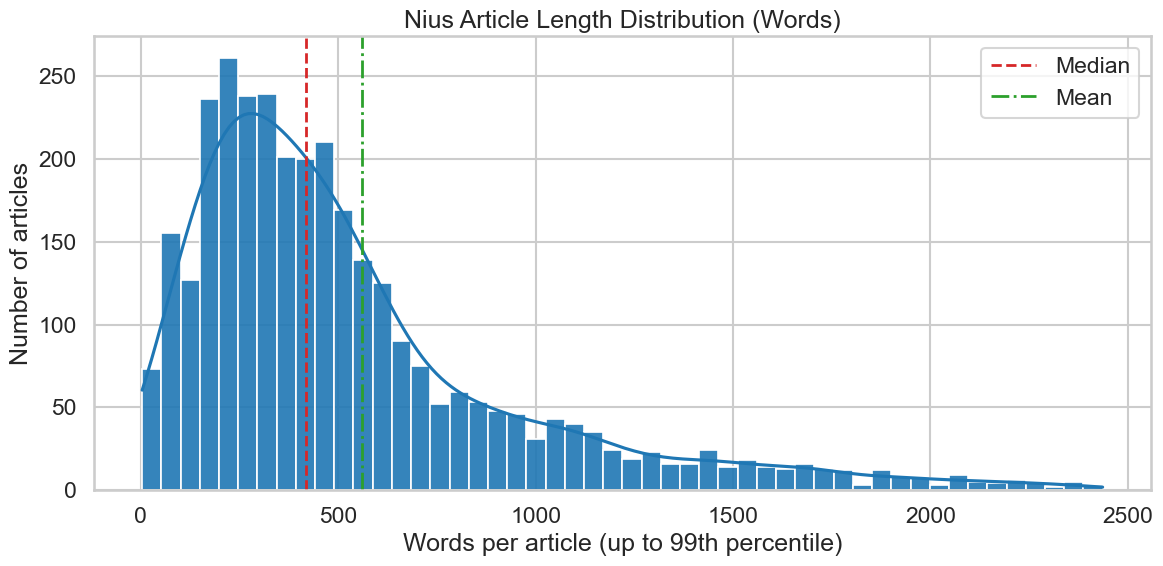

In [23]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Nius Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_clean

## BERTopic

In [75]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [76]:
from BERTopic.bertopic_config import BERTopicConfig
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [77]:
df_clean[["title", "article_text"]].head()


,title,article_text
1424,Das Bürgergeld-Leben der afghanischen Familie B.,# Das Bürgergeld-Leben der afghanischen Famili...
1425,Die Planwirtschaft von Ursula von der Leyen ha...,# Die Planwirtschaft von Ursula von der Leyen ...
1426,Jeder vierte Ausländer (20-25) geht nicht zu S...,# Jeder vierte Ausländer (20-25) geht nicht zu...
1427,Polizei schickt Deutschen Schäferhund in Rente,# Polizei schickt Deutschen Schäferhund in Ren...
1428,Kosovo-Clan schlägt Frau auf offener Straße zu...,# Kosovo-Clan schlägt Frau auf offener Straße ...


In [82]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3271 entries, 1424 to 4702
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         3271 non-null   object        
 1   categories    3271 non-null   object        
 2   day           3271 non-null   datetime64[ns]
 3   authors       3270 non-null   object        
 4   article_text  3271 non-null   object        
 5   url           3271 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 178.9+ KB


In [ ]:
result = run_bertopic_pipeline(
    df=df_clean,
    text_col="article_text",
    config = BERTopicConfig(min_df=2),
    id_col="url",
    source_name="Nius",
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-07 11:13:32,599 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/102 [00:00<?, ?it/s]

2026-03-07 11:14:00,572 - BERTopic - Embedding - Completed ✓
2026-03-07 11:14:00,573 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-07 11:14:12,086 - BERTopic - Dimensionality - Completed ✓
2026-03-07 11:14:12,089 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-07 11:14:12,184 - BERTopic - Cluster - Completed ✓
2026-03-07 11:14:12,193 - BERTopic - Representation - Fine-tuning topics using representation models.


ValueError: max_df corresponds to < documents than min_df

In [80]:
topic_info = result["topic_info"]
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,0,2986,0_union_europa_stadt_zeigt,"[union, europa, stadt, zeigt, wirtschaft, 2026...",[Ukraine-Verhandlungen: Wie Putin mit dem Prin...
1,1,194,1_war live_radio_geht direkt_aufzeichnung,"[war live, radio, geht direkt, aufzeichnung, b...",[Das war NIUS Live am Freitag: Der Wortbruchka...
2,2,80,2_kirks_robinson_mord_epstein,"[kirks, robinson, mord, epstein, gewalt, utah,...",[In nur 48 Stunden: „Turning Point USA“ erhiel...


In [ ]:
doc_info = result["doc_info"]
doc_info.head()


,original_index,document_id,source_name,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,1424,https://www.nius.de/gesellschaft/news/buergerg...,Nius,Das Bürgergeld-Leben der afghanischen Familie ...,0,0_migranten_migration_ausländer_millionen,"[migranten, migration, ausländer, millionen, b...",[Muster-Migranten statt harter Fakten: So rede...,migranten - migration - ausländer - millionen ...,1.000000,False
1,1425,https://www.nius.de/politik/news/die-planwirts...,Nius,Die Planwirtschaft von Ursula von der Leyen ha...,27,27_vw_porsche_mercedes_volkswagen,"[vw, porsche, mercedes, volkswagen, china, kon...",[China-Geschäft eingebrochen: Krise der deutsc...,vw - porsche - mercedes - volkswagen - china -...,0.196469,False
2,1426,https://www.nius.de/gesellschaft/news/jeder-vi...,Nius,Jeder vierte Ausländer (20-25) geht nicht zu S...,0,0_migranten_migration_ausländer_millionen,"[migranten, migration, ausländer, millionen, b...",[Muster-Migranten statt harter Fakten: So rede...,migranten - migration - ausländer - millionen ...,1.000000,False
3,1427,https://www.nius.de/kommentar/news/polizei-sch...,Nius,Polizei schickt Deutschen Schäferhund in Rente...,5,5_berliner_demokratie_wegner_bürger,"[berliner, demokratie, wegner, bürger, angst, ...",[Folgt Kanzler Stromberg nicht in den Abgrund!...,berliner - demokratie - wegner - bürger - angs...,0.632698,False
4,1428,https://www.nius.de/kriminalitaet/news/kosovo-...,Nius,Kosovo-Clan schlägt Frau auf offener Straße zu...,12,12_liana_friedland_16_jährige,"[liana, friedland, 16, jährige, täter, tat, mu...",[Iraker wirft 16-Jährige vor den Zug: Das Prot...,liana - friedland - 16 - jährige - täter - tat...,0.694128,False


In [ ]:
nius_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

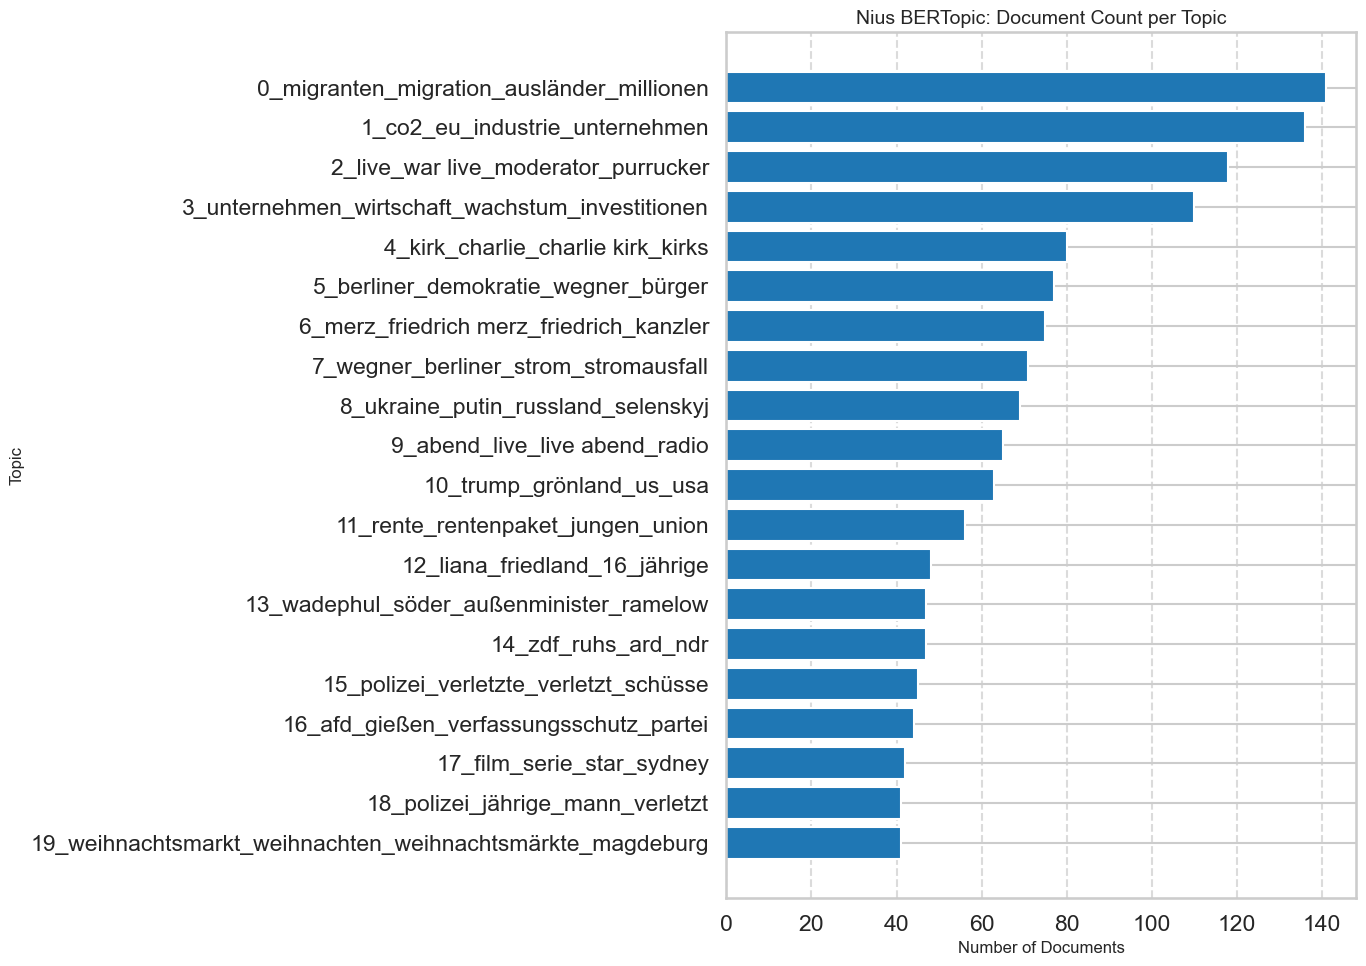

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.nlargest(20, 'Count').sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('Nius BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:03,  1.86it/s]


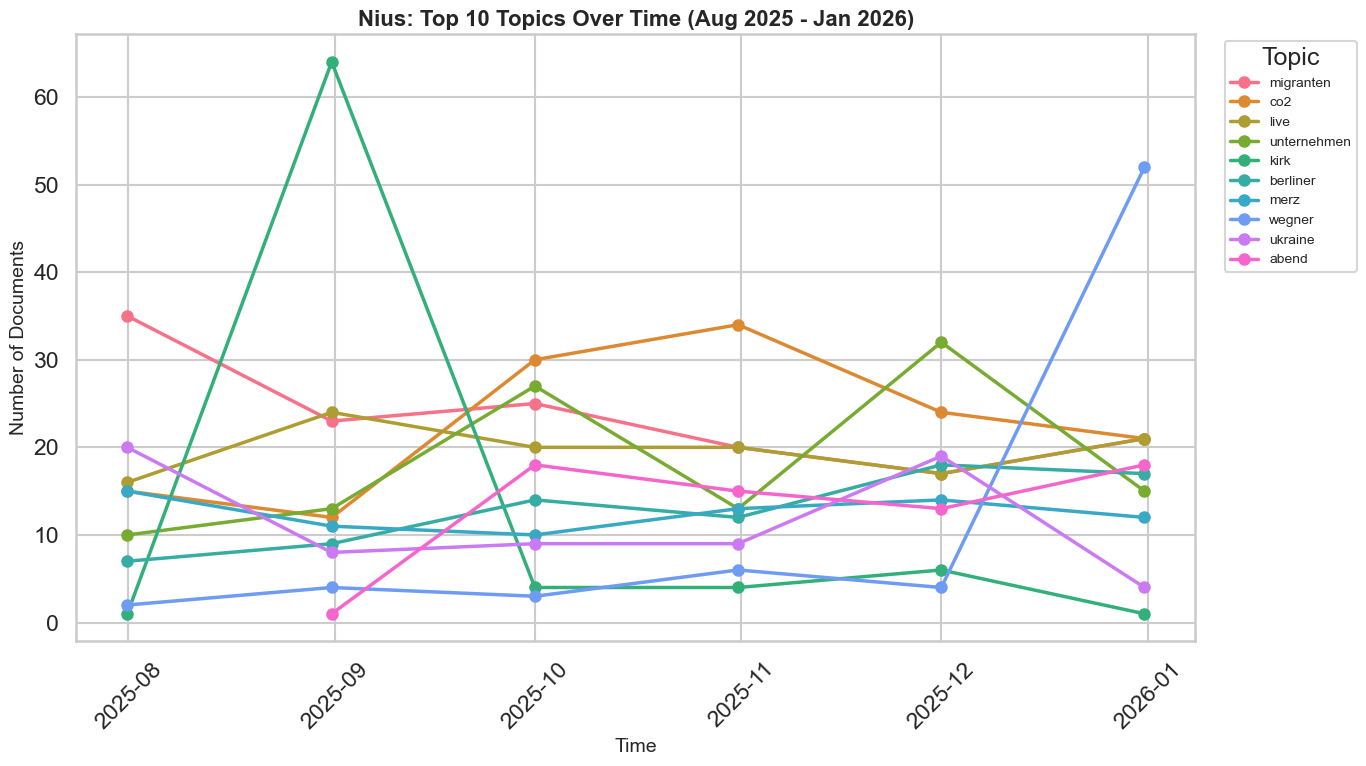

In [ ]:
# Prepare data for topics over time
topics_over_time = result["topic_model"].topics_over_time(
    result["docs"],
    result["prepared_documents"]["day"].tolist(),
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('Nius: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
topic_info = result["topic_info"]

topic_info_view = topic_info.drop(columns=["Representative_Docs"], errors="ignore")

with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None
):
    display(topic_info_view.head(20))

BERTopic #2

In [ ]:
from transformers import pipeline
import pandas as pd

pipeline_classification_topics = pipeline(
    "text-classification",
    model="chkla/parlbert-topic-german",
    return_all_scores=False,
)

def prepare_for_classifier(text, max_chars=2000):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    # Simple truncation for first-pass testing
    return text[:max_chars]

nius_cls = df_clean.copy()
nius_cls = nius_cls.dropna(subset=["article_text"]).copy()
nius_cls["clf_input"] = nius_cls["article_text"].map(prepare_for_classifier)

predictions = []
scores = []

for text in nius_cls["clf_input"]:
    if not text:
        predictions.append(None)
        scores.append(None)
        continue
    result = pipeline_classification_topics(text)[0]
    predictions.append(result["label"])
    scores.append(result["score"])

nius_cls["parlbert_topic"] = predictions
nius_cls["parlbert_score"] = scores

nius_cls[["title", "parlbert_topic", "parlbert_score"]].head(20)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: chkla/parlbert-topic-german
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/354 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (528 > 512). Running this sequence through the model will result in indexing errors


RuntimeError: The size of tensor a (528) must match the size of tensor b (512) at non-singleton dimension 1

In [ ]:
# BERTopic v2 run: full text first, then title-only
from BERTopic.bertopic_pipelinev2 import (
    BERTopicV2Config,
    BERTopicV2ConfigTitle,
    run_bertopic_pipeline,
)

result_full_text_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="article_text",
    config=BERTopicV2Config(),
    id_col="url",
    source_name="Nius",
)

result_title_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="title",
    config=BERTopicV2ConfigTitle(),
    id_col="url",
    source_name="Nius",
)

print(
    f"v2 full-text docs: {len(result_full_text_v2['docs']):,} | "
    f"v2 title docs: {len(result_title_v2['docs']):,}"
)

